# Week 01: Intro to Python, GitHub and Jupyter Notebooks

`<!-- TODO: Markdown Cells -->`

### Markdown Reference:

#### https://www.markdownguide.org/cheat-sheet/

In [5]:
# TODO: Code Cells
x = 2 * 2
print(x)
display(x)

4


4

## Fancy calculator

Programming languages have built-in math capabilities.

Can easily do algebra ($+$, $-$, $\times$, $\div$, $2^2$, $\sqrt{2}$) with numbers and variables.

Sometimes we have to be careful about _floating point_ numbers versus whole numbers (_int_).

In [9]:
# TODO: algebra
def alg(x):
    x ** 2
    return x
alg(10)
# TODO: variables

# TODO: int/float
int(37/8)
float(32)
1//3

0

## Functions

In [16]:
# TODO: Functions
def abs_diff(A, B):
    return abs(A - B)
abs_diff(120, 132)

def quadratic(a, b, c):
    square_term = (b * b - 4*a*c) ** 0.5
    sol1 = (-b + square_term) / 2 * a
    sol2 = (-b - square_term) / 2 * a
    return sol1, sol2


In [ ]:
# solving 2x**2 + 4x - 4 = 0 solve for x
x1, x2 = quadratic(2, 4, -4)
print(x1, x2)

2.9282032302755088 -10.928203230275509


## Using other people's code

We can easily import pre-built modules into our code

In [ ]:
# TODO: import libraries to load text and image from URLs

import requests  # for accessing URLs
import io        # for working with raw bytes
import PIL.Image # for working with images


data_res = requests.get("https://apod.as93.net/apod")
print(data_res)
type(data_res)
data = data_res.json()
type(data)
for key, value in data.items():
    print(f"{key}: {value}")

<Response [200]>
copyright: 
Włodzimierz Bubak; 
Text: Ogetay Kayali 
(MTU) 

date: 2026-01-27
explanation: Rising over a frozen valley in the Tatra Mountains, the familiar stars and nebulas of Orion dominate this wide-field nightscape.  The featured deep photo was taken in southern Poland's highest mountain range last month, where dark skies and alpine terrain combined to reveal both Earth's rugged beauty and the structure of our galaxy.  Above the snowy mountains, Orion's bright belt stars anchor a region of glowing interstellar clouds.  The Great Orion Nebula, a vast stellar nursery visible even to the unaided eye, shines near the center of the scene.  Surrounding it is the enormous arc of Barnard's Loop, a faint shell of ionized hydrogen gas spanning much of the constellation.  To the left, the round Rosette Nebula glows softly, while the grayish Witch Head Nebula hovers to the right, illuminated by nearby starlight.  Near the top, the orange supergiant Betelgeuse marks the hunter'

In [54]:
images_res = requests.get(data['url'])
images = io.BytesIO(images_res.content)
img = PIL.Image.open(images)
print(img)

<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=960x1200 at 0x106B0E0C0>


In [57]:
data_res = requests.get("https://google.com/search?udm=2&q=gutetama")
data = data_res.text
data

'<!DOCTYPE html PUBLIC "-//WAPFORUM//DTD XHTML Mobile 1.0//EN" "http://www.wapforum.org/DTD/xhtml-mobile10.dtd"><html xmlns="http://www.w3.org/1999/xhtml" lang="en"><head><meta content="application/xhtml+xml; charset=UTF-8" http-equiv="Content-Type"/><meta content="no-cache" name="Cache-Control"/><title>gutetama - Google Search</title><style>a{text-decoration:none;color:inherit}a:hover{text-decoration:underline}a img{border:0}body{font-family:sans-serif;padding:8px;margin:0 auto;max-width:700px;min-width:240px;}.FbhRzb{border-left:thin solid #dadce0;border-right:thin solid #dadce0;border-top:thin solid #dadce0;height:40px;overflow:hidden}.n692Zd{margin-bottom:10px}.cvifge{height:40px;border-spacing:0}.QvGUP{height:40px;padding:0 8px 0 8px;vertical-align:top}.O4cRJf{height:40px;width:100%;padding:0;padding-right:14px}.O1ePr{height:40px;padding:0;vertical-align:top}.kgJEQe{height:36px;width:98px;vertical-align:top;margin-top:4px}.lXLRf{vertical-align:top}.MhzMZd{border:0;vertical-align:m

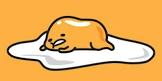

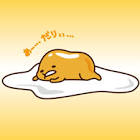

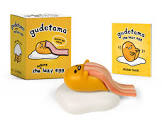

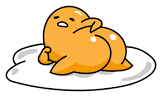

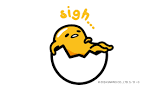

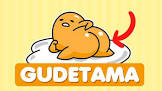

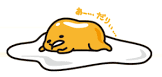

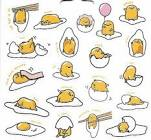

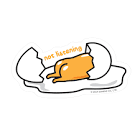

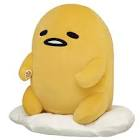

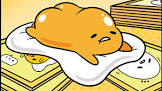

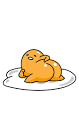

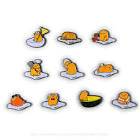

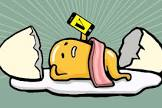

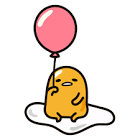

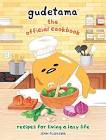

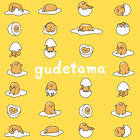

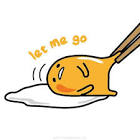

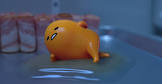

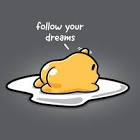

In [84]:
import re

pattern = r"https:\/\/[^\"\']+"
img_urls = re.findall(pattern, data)


for idx, url in enumerate(img_urls):
    if "gstatic" not in url:
        continue
    images_res = requests.get(url)
    images = io.BytesIO(images_res.content)
    img = PIL.Image.open(images)
    display(img)
    img.convert("RGB").save(f"./gudetama/gu_{idx}.jpg")

## Exercise

### Find the distance between New York City and the city where you're from

If you're from NYC, find distance between NYC and the furthest city you've ever visited, or are interested in visiting (like, Addis Ababa, ET).

There are a couple of ways to interpret this question. The more accurate answer would involve finding the path an airplane would travel, straight along a "[great arc](https://en.wikipedia.org/wiki/Great-circle_distance)", to calculate the distance.

But, as a first approximation, let's assume we're measuring this distance on a $2D$ map of the earth. We can then use latitude and longitude values to calculate the Euclidean distance between the $2$ cities.

Let's break this down into steps:

1. Find latitude and longitude values for NYC and the other city. You could look this up, but consider using the `requests` library to access an API like the `Open-Meteo` geocoding service ([LINK](https://open-meteo.com/en/docs/geocoding-api)) in order to make the whole thing more modular and reusable. This also has the advantage of giving the coordinates in decimal degrees, instead of degrees,minutes,seconds, which is more complicated to work with.

2. Take a look at the Wikipedia article about Euclidean Distances, specifically the part about distances on a plane ([LINK](https://en.wikipedia.org/wiki/Euclidean_distance#Two_dimensions)).

3. Write a `python` function that takes $2$ pairs of coordinates and returns the Euclidean distance between them. This basically implements the following formula from the Wikipedia article: ${\displaystyle \text{distance} = {\sqrt {(\varphi_{2}-\varphi_{1})^{2}+(\lambda_{2}-\lambda_{1})^{2}}}}$, where $(\varphi_1, \lambda_1)$ and $(\varphi_2, \lambda_2)$ are the latitude and longitude locations of the $2$ cities.

4. The above formula gives the result in radians (or degrees). In order to convert this to distance in km, we have to multiply the result by $6371$ (if using radians), or $111$ (if using degrees).

Hints:

- The `math` library has functions that can help.<br>We can square a value with `math.pow(x, 2)` and take the square root of a value with `math.sqrt(y)`.

- Here's an example URL for the `Open-Meteo` geocoding service:<br>
  [`https://geocoding-api.open-meteo.com/v1/search?name=sao%20paulo&countryCode=BR`](https://geocoding-api.open-meteo.com/v1/search?name=sao%20paulo&countryCode=BR)

- $(\varphi_1, \lambda_1)$ and $(\varphi_2, \lambda_2)$ are the $2$ pairs of coordinates for our cities.<br>$\varphi$ are the latitude values and $\lambda$ the longitude values.

In [ ]:
import math
import requests

# TODO: lat/lon for NYC and city2

# TODO: implement euclidean distance function
def euclidean_distance(lat0, lon0, lat1, lon1):
  print("implement here")

## Questions

- In which cases does our calculation completely fail ?
  - How far is Tokyo from Anchorage ?
- How might we fix it ?

## Bonus

### How different is the result if we compute the actual distance along the great arc connecting the $2$ cities?

Here are the steps needed to do that:

1. Find latitude and longitude values for NYC and the other city. You could look this up, but consider using the `requests` library to access an API like the `Open-Meteo` geocoding service ([LINK](https://open-meteo.com/en/docs/geocoding-api)) in order to make the whole thing more modular and reusable.

2. Take a look at the Wikipedia article about the haversine formula ([LINK](https://en.wikipedia.org/wiki/Haversine_formula)), specifically the [#Formulation](https://en.wikipedia.org/wiki/Haversine_formula#Formulation) and [#Example](https://en.wikipedia.org/wiki/Haversine_formula#Example) sections.

3. Given a pair of latitude and longitude values (labeled as $(\varphi_1, \lambda_1)$ and $(\varphi_2, \lambda_2)$ in the Wikipedia article), calculate the central angle between the $2$ points (labeled $\theta$ on Wikipedia).

4. The distance between the $2$ points is $\theta$ multiplied by the radius of the Earth (which is approximately 6371 km)

## Hints
<details>
  <summary style="font-size: 1.25em;">General</summary>

  The `math` library has trigonometric functions like `cos()`, `sin()`, `acos()`, `asin()` etc.

  These functions expect the inputs to be in `radians`.

  You can convert degrees to radians using `math.radians()`.
</details><br>

<details>
  <summary style="font-size: 1.25em;">Step 1</summary>

  Here's an example URL for the `Open-Meteo` geocoding service:<br>
  [`https://geocoding-api.open-meteo.com/v1/search?name=sao%20paulo&countryCode=BR`](https://geocoding-api.open-meteo.com/v1/search?name=sao%20paulo&countryCode=BR)
</details><br>

<details>
  <summary style="font-size: 1.25em;">Step 2</summary>

  $(\varphi_1, \lambda_1)$ and $(\varphi_2, \lambda_2)$ are the $2$ pairs of coordinates for our cities.

  $\varphi$ are the latitude values and $\lambda$ the longitude values.

  We are looking to calculate $\theta$, the central angle between the two points
</details><br>

<details>
  <summary style="font-size: 1.25em;">Step 3</summary>

  Define `haversine()` and `inverse_haversine()` functions in `python`:

  $\operatorname{hav}(\theta) = \frac{1 - \cos(\theta)}{2}$ &emsp;&emsp;and&emsp;&emsp;
  $\operatorname{ihav}(\delta) = \cos^{-1}(1 - 2 \delta)$

  $\cos^{-1}()$ is the `math.acos()` function in `python`

  Compute $\operatorname{hav}(\theta) = \operatorname{hav}(\varphi_{2}-\varphi_{1}) + \cos(\varphi_{1}) \cos(\varphi_{2}) \operatorname{hav}(\lambda_{2}-\lambda_{1})$, and store the result in a variable called `hav_theta`

  The central angle between the $2$ cities ($\theta$ on the formulas in Wikipedia) is $\operatorname{ihav}(\operatorname{hav}(\theta))$

  $\operatorname{hav}(\theta)$ is stored in `hav_theta`, so calculating $\theta$ is just a matter of calling `inverse_haversine(hav_theta)`
  
  
</details><br>





In [ ]:
import math
import requests

# TODO: lat/lon for NYC and city2

# TODO: define haversine and inverse haversine functions
def haversine(t):
  print("implement here")

def inverse_haversine(d):
  print("implement here")

def haversine_dist(lat0, lon0, lat1, lon1):
  print("implement here")
  # TODO: compute hav_theta = hav + cos * cos * hav

  # TODO: solve for theta using inverse haversine function

  # TODO: compute distance by multiplying theta by 6371 (radius of earth)